In [2]:
import os
import itertools
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils import class_weight as cw_util
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt

In [3]:
plt.rcParams["figure.dpi"] = 120
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

BASE       = "/content/drive/MyDrive/dataset_ecg/ecg_data"
TRAIN_DIR  = os.path.join(BASE, "train")
TEST_DIR   = os.path.join(BASE, "test")
MODEL_PATH = "/content/drive/MyDrive/best_ecg_model_v6.keras"

print("Train existe:", os.path.isdir(TRAIN_DIR))
print("Test existe: ", os.path.isdir(TEST_DIR))

Mounted at /content/drive
Train existe: True
Test existe:  True


In [5]:
IMG_SIZE = (224, 224)
BATCH    = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    validation_split=0.2,
    subset="training",
    seed=SEED
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    validation_split=0.2,
    subset="validation",
    seed=SEED
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=False
)

class_names = train_ds.class_names
print("\nTrain classes:", train_ds.class_names)
print("Test classes: ", test_ds.class_names)

Found 3023 files belonging to 4 classes.
Using 2419 files for training.
Found 3023 files belonging to 4 classes.
Using 604 files for validation.
Found 928 files belonging to 4 classes.

Train classes: ['Normal', 'abnormal_heartbeat', 'history_mi', 'myocardial_infarction']
Test classes:  ['Normal', 'abnormal_heartbeat', 'history_mi', 'myocardial_infarction']


In [6]:
NORMAL_IDX = next(
    i for i, c in enumerate(class_names) if c.lower() == "normal"
)
print(f"\nÍndice de 'normal': {NORMAL_IDX} → clase 0")
print("Resto              → clase 1 (anormal)\n")

def convertir_binario(image, label):
    new_label = tf.where(label == NORMAL_IDX, 0, 1)
    return image, new_label

train_ds = train_ds.map(convertir_binario)
val_ds   = val_ds.map(convertir_binario)
test_ds  = test_ds.map(convertir_binario)


Índice de 'normal': 0 → clase 0
Resto              → clase 1 (anormal)



In [7]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.05),
], name="augmentation")


In [8]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)


In [9]:
y_train = np.concatenate([y.numpy() for _, y in train_ds], axis=0)
cw = cw_util.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(cw))
# print("Class weights:", class_weights)

In [10]:
# DenseNet121 conecta cada capa con todas las anteriores,
# lo que lo hace especialmente bueno para features médicas
base = DenseNet121(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)
base.trainable = False  # congelado en fase 1

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)

# DenseNet121 tiene su propio preprocesamiento
x = tf.keras.applications.densenet.preprocess_input(x)

x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

# ✅ Cabeza más profunda para mayor capacidad
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.1)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,337,025 (27.99 MB)

 Trainable params: 297,473 (1.13 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [11]:
def make_callbacks(patience):
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            MODEL_PATH,
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1
        )
    ]

In [12]:
print("\n" + "="*50)
print("FASE 1: Entrenando cabeza clasificadora")
print("="*50)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=make_callbacks(patience=4)
)


FASE 1: Entrenando cabeza clasificadora
Epoch 1/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5708 - loss: 0.7288
Epoch 1: val_loss improved from None to 0.60397, saving model to /content/drive/MyDrive/best_ecg_model_v6.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_ecg_model_v6.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 372s 5s/step - accuracy: 0.5978 - loss: 0.6700 - val_accuracy: 0.7368 - val_loss: 0.6040 - learning_rate: 1.0000e-04
Epoch 2/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6793 - loss: 0.6045
Epoch 2: val_loss improved from 0.60397 to 0.56838, saving model to /content/drive/MyDrive/best_ecg_model_v6.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_ecg_model_v6.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 336s 4s/step - accuracy: 0.6842 - loss: 0.5777 - val_accuracy: 0.7583 - val_loss: 0.5684 - learning_rate: 1.0000e-04
Epoch 3/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7139 - loss: 0.5602
Epoch 3: val_loss improved from

In [13]:
print("\n" + "="*50)
print("FASE 2: Fine-tuning (últimas 50 capas de DenseNet121)")
print("="*50)

base.trainable = True

# DenseNet121 tiene más capas que EfficientNetB0,
# descongelamos las últimas 50 para más capacidad
for layer in base.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-6),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=make_callbacks(patience=5)
)



FASE 2: Fine-tuning (últimas 50 capas de DenseNet121)
Epoch 1/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7765 - loss: 0.4884
Epoch 1: val_loss improved from None to 0.38436, saving model to /content/drive/MyDrive/best_ecg_model_v6.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_ecg_model_v6.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 380s 5s/step - accuracy: 0.7776 - loss: 0.4675 - val_accuracy: 0.7815 - val_loss: 0.3844 - learning_rate: 3.0000e-06
Epoch 2/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7754 - loss: 0.4830
Epoch 2: val_loss did not improve from 0.38436
76/76 ━━━━━━━━━━━━━━━━━━━━ 381s 5s/step - accuracy: 0.7735 - loss: 0.4613 - val_accuracy: 0.7666 - val_loss: 0.4029 - learning_rate: 3.0000e-06
Epoch 3/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7794 - loss: 0.4639
Epoch 3: val_loss did not improve from 0.38436

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.500000053056283e-06.
76/76 ━━━━━━━━━━━━━━━━━━━━ 388s 5s/step - a

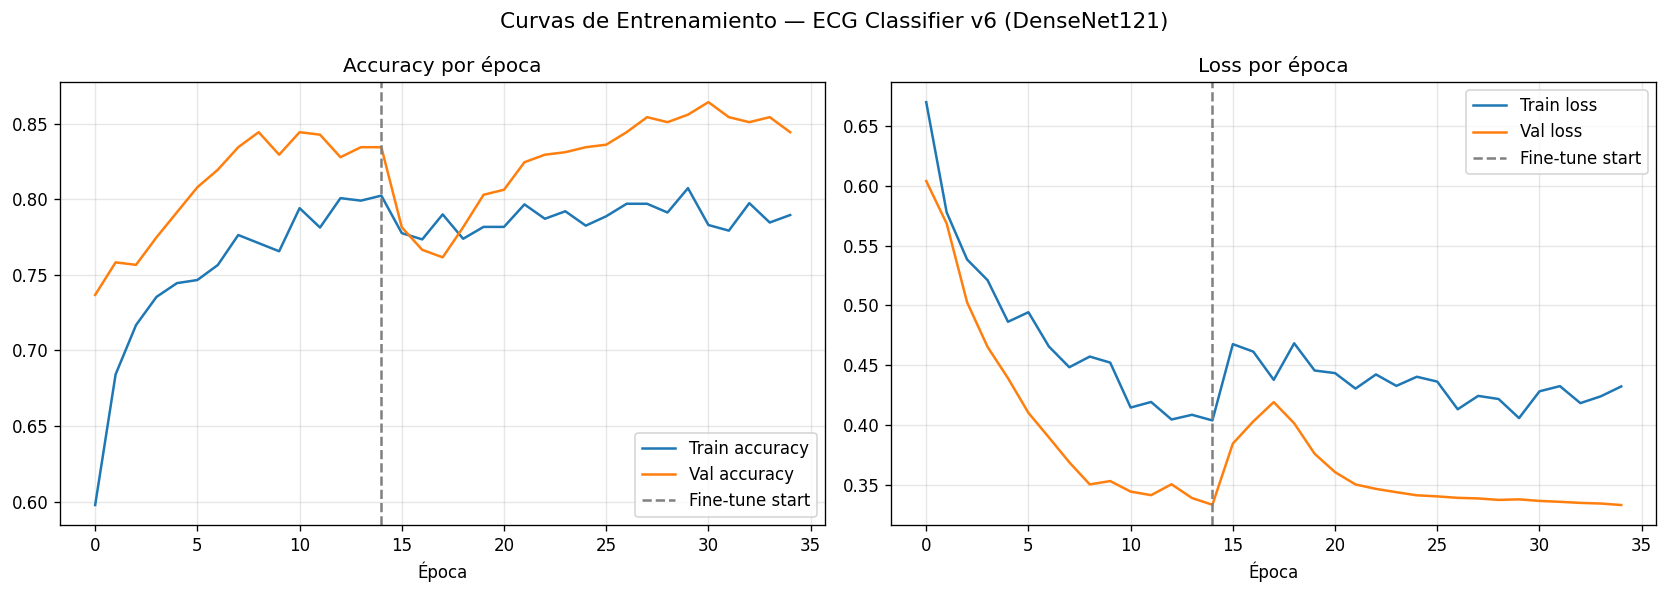

In [14]:
def plot_history(h1, h2):
    acc   = h1.history['accuracy']     + h2.history['accuracy']
    val_a = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss  = h1.history['loss']         + h2.history['loss']
    val_l = h1.history['val_loss']     + h2.history['val_loss']
    ep    = range(len(acc))
    split = len(h1.history['accuracy']) - 1

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(ep, acc,   label='Train accuracy')
    ax1.plot(ep, val_a, label='Val accuracy')
    ax1.axvline(split, color='gray', linestyle='--', label='Fine-tune start')
    ax1.set_title('Accuracy por época')
    ax1.set_xlabel('Época')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(ep, loss,  label='Train loss')
    ax2.plot(ep, val_l, label='Val loss')
    ax2.axvline(split, color='gray', linestyle='--', label='Fine-tune start')
    ax2.set_title('Loss por época')
    ax2.set_xlabel('Época')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle('Curvas de Entrenamiento — ECG Classifier v6 (DenseNet121)', fontsize=13)
    plt.tight_layout()
    plt.show()

plot_history(history, history_fine)

In [15]:
print("\nBuscando mejor threshold en validación...")

y_val_true = np.concatenate([y.numpy() for _, y in val_ds], axis=0)
probs_val  = model.predict(val_ds)

best_thresh = 0.5
best_f1     = 0.0

for thresh in np.arange(0.3, 0.7, 0.01):
    y_val_pred = (probs_val > thresh).astype(int).flatten()
    f1 = f1_score(y_val_true, y_val_pred, average='macro')
    if f1 > best_f1:
        best_f1     = f1
        best_thresh = thresh

print(f"✅ Mejor threshold: {best_thresh:.2f}  (f1-macro val: {best_f1:.4f})")


Buscando mejor threshold en validación...
19/19 ━━━━━━━━━━━━━━━━━━━━ 71s 4s/step
✅ Mejor threshold: 0.68  (f1-macro val: 0.8524)


29/29 ━━━━━━━━━━━━━━━━━━━━ 97s 3s/step


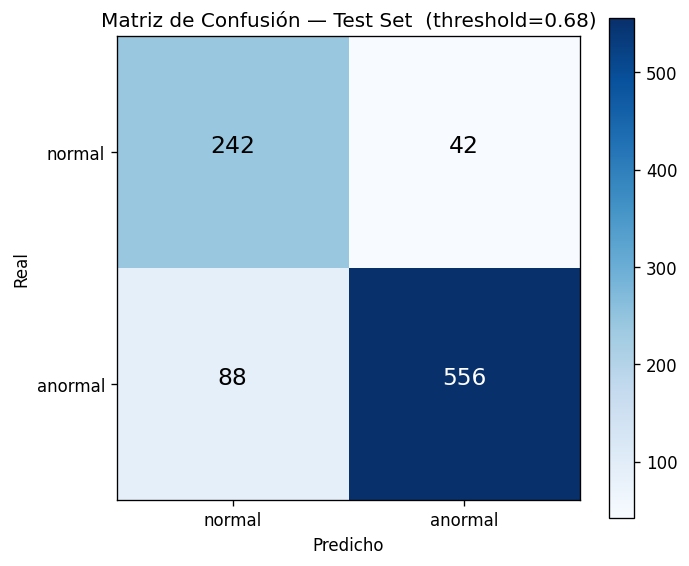


Classification Report:

              precision    recall  f1-score   support

      normal       0.73      0.85      0.79       284
     anormal       0.93      0.86      0.90       644

    accuracy                           0.86       928
   macro avg       0.83      0.86      0.84       928
weighted avg       0.87      0.86      0.86       928



In [16]:
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
probs  = model.predict(test_ds)
y_pred = (probs > best_thresh).astype(int).flatten()

labels = ["normal", "anormal"]

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title(f"Matriz de Confusión — Test Set  (threshold={best_thresh:.2f})")
plt.colorbar()
ticks = np.arange(2)
plt.xticks(ticks, labels)
plt.yticks(ticks, labels)
for i, j in itertools.product(range(2), range(2)):
    plt.text(j, i, cm[i, j],
             ha="center",
             color="white" if cm[i, j] > cm.max() / 2 else "black",
             fontsize=14)
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=labels))

In [17]:
model.save(MODEL_PATH)
# print(f"\n✅ Modelo guardado en: {MODEL_PATH}")

In [18]:
import os
from google.colab import files

MODEL_PATH = "/content/drive/MyDrive/best_ecg_model_v6.keras"

# Ver tamaño del modelo
size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
print(f"Tamaño del modelo: {size_mb:.1f} MB")

# Descargar a tu PC
files.download(MODEL_PATH)

Tamaño del modelo: 40.0 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>